# CropSight — Module 1: Data Ingestion

Downloads and validates all raw data for the US Corn Belt yield forecasting pipeline.

**Data sources:**
| Source | Variable | Resolution | Access |
|--------|----------|------------|--------|
| USDA NASS QuickStats | Corn yield (bu/acre) | County × Year | REST API |
| NASA AppEEARS / GEE | MODIS MOD13Q1 NDVI | 250m, 16-day | GEE Python API |
| Copernicus CDS | ERA5 temperature, precip, radiation | 0.25°, hourly→daily | `cdsapi` |
| CHIRPS | Daily precipitation | 0.05° | HTTP download |
| USDA CDL | Cropland classification mask | 30m, annual | REST API |
| SSURGO | Soil properties | County polygon | `pysoilmap` / CSV |

**States:** Iowa (IA), Illinois (IL), Indiana (IN)  
**Years:** 2000–2023  
**Output:** `data/raw/` directory with standardised files

---
> **Setup required before running** — see Section 0 for API keys and package installs.

## 0 · Environment setup

### 0.1 Install packages
Run this once in your terminal (not in the notebook):

```bash
conda create -n cropsight python=3.10
conda activate cropsight
pip install earthengine-api geemap cdsapi requests pandas geopandas xarray
pip install rasterio shapely tqdm python-dotenv zarr netCDF4 h5netcdf
```

### 0.2 API credentials
Create a `.env` file in your project root with:

```
NASS_API_KEY=your_key_here
```

- **NASS key**: free at https://quickstats.nass.usda.gov/api  
- **GEE**: run `earthengine authenticate` in terminal after install  
- **CDS (ERA5)**: register at https://cds.climate.copernicus.eu, add `~/.cdsapirc`

### 0.3 CDS API config (~/.cdsapirc)
```
url: https://cds.climate.copernicus.eu/api/v2
key: YOUR_UID:YOUR_API_KEY
```

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os
import time
import json
import zipfile
import requests
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm.notebook import tqdm
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

print('Imports OK')
print(f'pandas {pd.__version__} | xarray {xr.__version__} | geopandas {gpd.__version__}')

Imports OK
pandas 2.3.3 | xarray 2025.6.1 | geopandas 1.1.3


In [2]:
# ── Project config ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_INTERIM = PROJECT_ROOT / 'data' / 'interim'

for d in [DATA_RAW / 'nass', DATA_RAW / 'modis', DATA_RAW / 'era5',
          DATA_RAW / 'chirps', DATA_RAW / 'cdl', DATA_RAW / 'soil',
          DATA_INTERIM]:
    d.mkdir(parents=True, exist_ok=True)

# Target region
STATES      = ['IA', 'IL', 'IN']
STATE_FIPS  = {'IA': '19', 'IL': '17', 'IN': '18'}
YEARS       = list(range(2000, 2024))   # 2000–2023 inclusive
TRAIN_YEARS = list(range(2000, 2022))
TEST_YEARS  = [2022, 2023]

# Corn Belt bounding box (lon_min, lat_min, lon_max, lat_max)
BBOX = (-97.5, 36.5, -84.5, 46.5)

NASS_API_KEY = os.getenv('NASS_API_KEY', '')
if not NASS_API_KEY:
    print('⚠  NASS_API_KEY not found in .env — NASS cell will be skipped')
else:
    print(f'✓  NASS key loaded ({NASS_API_KEY[:6]}...)')

print(f'\nProject root : {PROJECT_ROOT}')
print(f'Data raw     : {DATA_RAW}')
print(f'Years        : {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} seasons)')

✓  NASS key loaded (5E03C9...)

Project root : C:\Users\taylo\cropsight-cornbelt
Data raw     : C:\Users\taylo\cropsight-cornbelt\data\raw
Years        : 2000–2023 (24 seasons)


---
## 1 · USDA NASS — county corn yield

Pulls corn grain yield (bu/acre) for every county in IA, IL, IN from 2000–2023.  
Cleans suppressed values, detrends (optional), and saves to `data/raw/nass/`.

In [3]:
# ── 1.1  NASS QuickStats API pull ─────────────────────────────────────────────
NASS_BASE = 'https://quickstats.nass.usda.gov/api/api_GET/'

def fetch_nass_yield(state_abbr: str, year_start: int, year_end: int) -> pd.DataFrame:
    """
    Fetch corn grain yield at county level from NASS QuickStats.
    Returns a tidy DataFrame with columns:
      state, county_name, county_ansi, year, yield_bu_acre
    """
    params = {
        'key'          : NASS_API_KEY,
        'commodity_desc': 'CORN',
        'statisticcat_desc': 'YIELD',
        'unit_desc'    : 'BU / ACRE',
        'domain_desc'  : 'TOTAL',
        'agg_level_desc': 'COUNTY',
        'state_alpha'  : state_abbr,
        'year__GE'     : str(year_start),
        'year__LE'     : str(year_end),
        'format'       : 'JSON',
    }
    resp = requests.get(NASS_BASE, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json().get('data', [])
    if not data:
        print(f'  ⚠  No data returned for {state_abbr}')
        return pd.DataFrame()

    df = pd.DataFrame(data)[[
        'state_alpha', 'county_name', 'county_ansi', 'year', 'Value'
    ]].rename(columns={
        'state_alpha'  : 'state',
        'Value'        : 'yield_bu_acre'
    })

    # Cast types; NASS returns suppressed values as ' (D)' or ' (Z)'
    df['year']          = df['year'].astype(int)
    df['county_ansi']   = df['county_ansi'].str.zfill(3)
    df['yield_bu_acre'] = pd.to_numeric(df['yield_bu_acre'], errors='coerce')

    # Create 5-digit FIPS = state_fips + county_ansi
    fips_map = {'IA': '19', 'IL': '17', 'IN': '18'}
    df['fips'] = fips_map[state_abbr] + df['county_ansi']

    return df.dropna(subset=['yield_bu_acre'])


if NASS_API_KEY:
    frames = []
    for state in tqdm(STATES, desc='Fetching NASS yield'):
        df_state = fetch_nass_yield(state, YEARS[0], YEARS[-1])
        frames.append(df_state)
        time.sleep(0.5)   # polite rate limiting

    nass_df = pd.concat(frames, ignore_index=True)
    out_path = DATA_RAW / 'nass' / 'corn_yield_county_2000_2023.csv'
    nass_df.to_csv(out_path, index=False)

    print(f'\n✓  Saved {len(nass_df):,} rows → {out_path}')
    print(nass_df.groupby('state')['yield_bu_acre'].describe().round(1))
else:
    print('Skipped — set NASS_API_KEY in .env')

Fetching NASS yield:   0%|          | 0/3 [00:00<?, ?it/s]


✓  Saved 6,954 rows → C:\Users\taylo\cropsight-cornbelt\data\raw\nass\corn_yield_county_2000_2023.csv
        count   mean   std   min    25%    50%    75%    max
state                                                       
IA     2406.0  173.8  27.4  44.5  157.1  175.8  193.2  240.9
IL     2402.0  167.5  35.8  19.0  146.4  170.0  191.7  248.2
IN     2146.0  160.6  29.6  30.1  145.2  162.1  181.0  234.4


In [4]:
# ── 1.2  Validate and quick-look ───────────────────────────────────────────────
nass_df = pd.read_csv(DATA_RAW / 'nass' / 'corn_yield_county_2000_2023.csv',
                      dtype={'fips': str, 'county_ansi': str})

# Coverage check: every state × year combo should have many counties
coverage = nass_df.groupby(['state', 'year'])['fips'].count().unstack('state')
print('County count per state × year (first 5 / last 5 rows):')
print(pd.concat([coverage.head(), coverage.tail()]))

# Check for any years with suspicious drops
annual_mean = nass_df.groupby('year')['yield_bu_acre'].mean()
low_years = annual_mean[annual_mean < annual_mean.mean() - 2 * annual_mean.std()]
if not low_years.empty:
    print(f'\nFlagged low-yield years (likely drought): {low_years.index.tolist()}')
    print('  → 2012 expected (major Corn Belt drought)')

print(f'\nUnique FIPS codes : {nass_df["fips"].nunique()}')
print(f'Missing yield rows: {nass_df["yield_bu_acre"].isna().sum()}')

County count per state × year (first 5 / last 5 rows):
state  IA   IL  IN
year              
2000   99  102  89
2001   99  102  89
2002   99  102  89
2003   99  102  89
2004   99  102  89
2020   96  100  90
2021   85   80  74
2022   98   95  82
2023   88   92  75
2024   74   63  72

Flagged low-yield years (likely drought): [2012]
  → 2012 expected (major Corn Belt drought)

Unique FIPS codes : 296
Missing yield rows: 0


---
## 2 · MODIS NDVI via Google Earth Engine

Exports county-level mean NDVI from MOD13Q1 (250 m, 16-day composites).  
We mask non-cropland pixels using the CDL before aggregating — this is critical  
to avoid diluting the signal with forests, water, and urban areas.

**Two paths depending on your GEE setup:**
- Path A (recommended): Export via `geemap` to Google Drive, then download  
- Path B (offline fallback): Direct pixel pull via `earthengine-api` for small AOIs

> First-time GEE setup: run `earthengine authenticate` in terminal, then `earthengine initialize`

In [5]:
# ── 2.1  Initialise GEE ───────────────────────────────────────────────────────
try:
    import ee
    ee.Initialize(project='cropsight-cornbelt')
    print('✓  GEE initialised')
    GEE_AVAILABLE = True
except Exception as e:
    print(f'⚠  GEE not available: {e}')
    print('   Run: earthengine authenticate  (then restart kernel)')
    GEE_AVAILABLE = False

✓  GEE initialised


In [6]:
# ── 2.2  Helper functions ─────────────────────────────────────────────────────
def mask_modis_clouds(img):
    """
    Mask MODIS MOD13Q1 using the DetailedQA band.
    Keeps only pixels where bits 0-1 == 00 (good data) or 01 (marginal).
    """
    qa = img.select('DetailedQA')
    vi_quality = qa.bitwiseAnd(0b11)            # bits 0–1: VI quality
    good = vi_quality.lte(1)                    # 0 = good, 1 = marginal
    return img.updateMask(good)


def get_corn_belt_counties():
    """
    Load Iowa, Illinois, Indiana county boundaries from GEE's TIGER dataset.
    Returns an ee.FeatureCollection with a 'fips' property.
    """
    counties = ee.FeatureCollection('TIGER/2018/Counties')
    corn_belt = counties.filter(
        ee.Filter.inList('STATEFP', ['19', '17', '18'])
    )
    # Build fips server-side only — no .getInfo() inside map
    def add_fips(feat):
        return feat.set(
            'fips',
            ee.String(feat.get('STATEFP')).cat(ee.String(feat.get('COUNTYFP')))
        )
    return corn_belt.map(add_fips)

print('get_corn_belt_counties() redefined')

def extract_county_ndvi(year: int, counties_fc) -> pd.DataFrame:
    """
    For a given year, extract mean NDVI per county per 16-day period.
    Returns a DataFrame with columns: fips, date, ndvi_mean, ndvi_std, pixel_count
    """
    start = f'{year}-03-01'   # start of growing season window
    end   = f'{year}-11-30'   # end of growing season window

    modis = (
        ee.ImageCollection('MODIS/061/MOD13Q1')
          .filterDate(start, end)
          .select(['NDVI', 'DetailedQA'])
          .map(mask_modis_clouds)
    )

    def reduce_image(img):
        date_str = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
        ndvi = img.select('NDVI').multiply(0.0001)   # scale factor

        stats = ndvi.reduceRegions(
            collection=counties_fc,
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.stdDev(), sharedInputs=True
            ).combine(
                ee.Reducer.count(), sharedInputs=True
            ),
            scale=250,
            crs='EPSG:4326'
        )
        return stats.map(lambda f: f.set('date', date_str))

    results = modis.map(reduce_image).flatten()

    # Pull to local — returns a list of dicts
    rows = results.select(['fips', 'date', 'mean', 'stdDev', 'count']).getInfo()
    records = [
        {
            'fips'        : f['properties']['fips'],
            'date'        : f['properties']['date'],
            'ndvi_mean'   : f['properties'].get('mean'),
            'ndvi_std'    : f['properties'].get('stdDev'),
            'pixel_count' : f['properties'].get('count'),
        }
        for f in rows['features']
    ]
    return pd.DataFrame(records)


print('Helper functions defined')

get_corn_belt_counties() redefined
Helper functions defined


In [8]:
# ── 2.3  Run NDVI extraction (year by year) ───────────────────────────────────
YEARS_TO_PROCESS = YEARS   # 2000–2023
MODIS_OUT = DATA_RAW / 'modis'

if GEE_AVAILABLE:
    counties_fc = get_corn_belt_counties()

    for year in tqdm(YEARS_TO_PROCESS, desc='MODIS NDVI extraction'):
        out_file = MODIS_OUT / f'ndvi_county_{year}.parquet'
        if out_file.exists():
            print(f'  {year}: already exists, skipping')
            continue
        try:
            df_year = extract_county_ndvi(year, counties_fc)
            df_year['year'] = year
            df_year.to_parquet(out_file, index=False)
            print(f'  ✓  {year}: {len(df_year):,} rows saved')
        except Exception as e:
            print(f'  ✗  {year}: {e}')
        time.sleep(2)
else:
    print('GEE not available — skipping')

MODIS NDVI extraction:   0%|          | 0/24 [00:00<?, ?it/s]

  ✓  2000: 4,981 rows saved
  ✓  2001: 4,981 rows saved
  ✓  2002: 4,981 rows saved
  ✓  2003: 4,981 rows saved
  ✓  2004: 4,981 rows saved
  ✓  2005: 4,981 rows saved
  ✓  2006: 4,981 rows saved
  ✓  2007: 4,981 rows saved
  ✓  2008: 4,981 rows saved
  ✓  2009: 4,981 rows saved
  2010: already exists, skipping
  2011: already exists, skipping
  2012: already exists, skipping
  2013: already exists, skipping
  2014: already exists, skipping
  2015: already exists, skipping
  2016: already exists, skipping
  2017: already exists, skipping
  2018: already exists, skipping
  2019: already exists, skipping
  2020: already exists, skipping
  2021: already exists, skipping
  2022: already exists, skipping
  2023: already exists, skipping


In [9]:
# ── 2.4  Alternative: GEE Export to Google Drive (recommended for 24-year runs) ──
#
# This submits a batch export task — much more reliable than .getInfo() for
# large collections. Download the CSVs from Google Drive afterwards.

def submit_ndvi_export_task(year: int, counties_fc, drive_folder: str = 'CropSight_MODIS'):
    """
    Submit a GEE Export.table.toDrive task for one year.
    Monitor progress at: https://code.earthengine.google.com/tasks
    """
    start = f'{year}-03-01'
    end   = f'{year}-11-30'

    modis = (
        ee.ImageCollection('MODIS/061/MOD13Q1') 
          .filterDate(start, end)
          .select(['NDVI', 'DetailedQA'])
          .map(mask_modis_clouds)
    )

    def reduce_image(img):
        date_str = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
        ndvi = img.select('NDVI').multiply(0.0001)
        stats = ndvi.reduceRegions(
            collection=counties_fc,
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.stdDev(), sharedInputs=True
            ).combine(
                ee.Reducer.count(), sharedInputs=True
            ),
            scale=250,
            crs='EPSG:4326'
        )
        return stats.map(lambda f: f.set('date', date_str))

    results = modis.map(reduce_image).flatten()

    task = ee.batch.Export.table.toDrive(
        collection=results,
        description=f'ndvi_county_{year}',
        folder=drive_folder,
        fileNamePrefix=f'ndvi_county_{year}',
        fileFormat='CSV',
        selectors=['fips', 'date', 'mean', 'stdDev', 'count']
    )
    task.start()
    return task

if GEE_AVAILABLE:
    counties_fc = get_corn_belt_counties()
    tasks = []
    for year in [2012, 2020, 2023]:
        t = submit_ndvi_export_task(year, counties_fc)
        tasks.append((year, t))
        print(f'  Submitted task for {year}: {t.id}')
        time.sleep(1)
    print(f'\nMonitor at: https://code.earthengine.google.com/tasks')

# ── Uncomment to submit all export tasks ──
# if GEE_AVAILABLE:
#     tasks = []
#     for year in YEARS:
#         t = submit_ndvi_export_task(year, counties_fc)
#         tasks.append((year, t))
#         print(f'  Submitted task for {year}: {t.id}')
#         time.sleep(1)
#     print(f'\nMonitor at: https://code.earthengine.google.com/tasks')

#print('Export function defined — uncomment the block above to submit batch tasks')

  Submitted task for 2012: F2JNTDNGXLOX5H7M7XDFOO3V
  Submitted task for 2020: M6Q2YZ6I6NJGKLKLEZJNBXFV
  Submitted task for 2023: NP6JSKBOC7ZW6OXENFJ45NIA

Monitor at: https://code.earthengine.google.com/tasks


In [10]:
# ── 2.5  Consolidate all years into a single parquet ──────────────────────────
modis_files = sorted((DATA_RAW / 'modis').glob('ndvi_county_*.parquet'))

if modis_files:
    ndvi_df = pd.concat([pd.read_parquet(f) for f in modis_files], ignore_index=True)
    ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
    ndvi_df = ndvi_df.sort_values(['fips', 'date']).reset_index(drop=True)

    out_path = DATA_RAW / 'modis' / 'ndvi_county_2000_2023.parquet'
    ndvi_df.to_parquet(out_path, index=False)

    print(f'✓  Consolidated NDVI: {len(ndvi_df):,} rows')
    print(f'   FIPS codes     : {ndvi_df["fips"].nunique()}')
    print(f'   Date range     : {ndvi_df["date"].min()} → {ndvi_df["date"].max()}')
    print(f'   NDVI range     : {ndvi_df["ndvi_mean"].min():.3f} – {ndvi_df["ndvi_mean"].max():.3f}')
    print(f'   Missing values : {ndvi_df["ndvi_mean"].isna().sum():,} ({ndvi_df["ndvi_mean"].isna().mean():.1%})')
else:
    print('No NDVI parquet files found — run extraction above first')

✓  Consolidated NDVI: 119,544 rows
   FIPS codes     : 293
   Date range     : 2000-03-05 00:00:00 → 2023-11-17 00:00:00
   NDVI range     : -0.069 – 0.913
   Missing values : 0 (0.0%)


---
## 3 · ERA5 — daily weather (temperature, precipitation, radiation)

Downloads ERA5 reanalysis via the Copernicus CDS API.  
Variables: 2m temperature (T2m), total precipitation, surface solar radiation.  
Regrid to county centroids in the next step.

> ERA5 data is large — each year ~500 MB. Request one variable at a time.  
> CDS jobs queue on their servers; typical wait 5–30 min per request.

In [11]:
# ── 3.1  CDS API setup ────────────────────────────────────────────────────────
try:
    import cdsapi
    cds_client = cdsapi.Client()
    CDS_AVAILABLE = True
    print('✓  CDS client initialised')
except Exception as e:
    print(f'⚠  CDS not available: {e}')
    print('   1) Register at https://cds.climate.copernicus.eu')
    print('   2) Create ~/.cdsapirc with your key (see Section 0.3)')
    print('   3) pip install cdsapi')
    CDS_AVAILABLE = False

✓  CDS client initialised


In [12]:
# ── 3.2  ERA5 download function ───────────────────────────────────────────────

ERA5_VARIABLES = {
    '2m_temperature'                 : '2m_temperature',
    'total_precipitation'            : 'total_precipitation',
    'surface_solar_radiation_downwards': 'ssrd',
    '2m_dewpoint_temperature'        : '2m_dewpoint_temperature',  # for VPD
    '10m_u_component_of_wind'        : '10m_u_wind',
    '10m_v_component_of_wind'        : '10m_v_wind',
}

# Corn Belt bounding box for ERA5 (N/W/S/E in degrees)
ERA5_AREA = [47, -98, 36, -84]   # [N, W, S, E]

def download_era5_year(year: int, variable: str, out_dir: Path,
                       client: 'cdsapi.Client', overwrite: bool = False) -> Path:
    """
    Download ERA5 single-level daily data for one year and one variable.
    Saves as a NetCDF file. Returns the output path.

    ERA5 is hourly; we request all hours and aggregate to daily in Section 3.3.
    """
    var_short = ERA5_VARIABLES.get(variable, variable.replace(' ', '_'))
    out_file = out_dir / f'era5_{var_short}_{year}.nc'

    if out_file.exists() and not overwrite:
        print(f'  {year} {variable}: already exists, skipping')
        return out_file

    print(f'  Requesting {year} {variable} … (queued on CDS, may take minutes)')
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable'    : variable,
            'year'        : str(year),
            'month'       : [f'{m:02d}' for m in range(3, 12)],   # Mar–Nov
            'day'         : [f'{d:02d}' for d in range(1, 32)],
            'time'        : [f'{h:02d}:00' for h in range(0, 24)],
            'area'        : ERA5_AREA,
            'format'      : 'netcdf',
        },
        str(out_file)
    )
    print(f'  ✓  Saved → {out_file.name}')
    return out_file


print('ERA5 download function defined')
print(f'Variables to download: {list(ERA5_VARIABLES.keys())}')

ERA5 download function defined
Variables to download: ['2m_temperature', 'total_precipitation', 'surface_solar_radiation_downwards', '2m_dewpoint_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind']


In [13]:
# ── 3.3  Run ERA5 downloads ───────────────────────────────────────────────────
#
# TIP: Start with 2m_temperature and total_precipitation for 2000–2005
# to validate the pipeline before downloading all 24 years × 6 variables.
#
# Approximate storage: ~400 MB per variable per year → ~57 GB for all.
# Consider downloading to an external drive or cloud storage.

ERA5_OUT = DATA_RAW / 'era5'

# ── Uncomment to run ──
# if CDS_AVAILABLE:
#     for variable in list(ERA5_VARIABLES.keys())[:2]:   # start with 2 variables
#         for year in YEARS[:5]:                          # start with 5 years
#             download_era5_year(year, variable, ERA5_OUT, cds_client)

print('ERA5 download block ready — uncomment to run')
print('Suggested first run: 2m_temperature + total_precipitation, years 2000-2005')

ERA5 download block ready — uncomment to run
Suggested first run: 2m_temperature + total_precipitation, years 2000-2005


In [14]:
# ── 3.4  Aggregate ERA5 hourly → daily + regrid to county centroids ────────────
import rasterio
from rasterio.transform import from_bounds

def load_county_centroids() -> gpd.GeoDataFrame:
    """
    Load county boundary centroids for IA, IL, IN.
    Uses the Census TIGER shapefile bundled with geopandas.
    Returns GeoDataFrame with fips, geometry (point).
    """
    # Natural Earth counties (or use a local TIGER shapefile)
    # For production, download TIGER 2020 counties shapefile:
    # https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
    try:
        import geodatasets
        counties = gpd.read_file(geodatasets.get_path('naturalearth.land'))  # placeholder
    except Exception:
        print('  Using NASS county list to build centroids from FIPS')

    # Simpler fallback: use a pre-built FIPS centroid CSV
    # (available at: https://www.census.gov/geographies/reference-files.html)
    centroid_url = (
        'https://raw.githubusercontent.com/btskinner/spatial/master/data/county_centers.csv'
    )
    print('  Download county centroids CSV from Census or use local TIGER file')
    return None


def era5_to_county_daily(nc_path: Path, county_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Load an ERA5 NetCDF, aggregate hourly to daily, bilinear-interpolate
    to county centroid coordinates, return tidy DataFrame.

    Args:
        nc_path    : Path to ERA5 .nc file
        county_gdf : GeoDataFrame with 'fips', 'lon', 'lat' columns

    Returns:
        DataFrame with columns: fips, date, variable, value
    """
    ds = xr.open_dataset(nc_path)
    var_name = [v for v in ds.data_vars][0]   # first (only) variable

    # ERA5 uses expver dimension sometimes — drop it
    if 'expver' in ds.dims:
        ds = ds.sel(expver='0001', drop=True)

    # Aggregate hourly → daily
    if var_name == 'tp':   # total precipitation is accumulated → sum
        daily = ds[var_name].resample(time='1D').sum()
    else:
        daily = ds[var_name].resample(time='1D').mean()

    records = []
    for _, row in county_gdf.iterrows():
        # Nearest-neighbour interpolation to county centroid
        county_vals = daily.sel(
            longitude=row['lon'],
            latitude=row['lat'],
            method='nearest'
        ).values
        dates = pd.to_datetime(daily.time.values)
        for d, v in zip(dates, county_vals):
            records.append({'fips': row['fips'], 'date': d, var_name: float(v)})

    return pd.DataFrame(records)


print('ERA5 aggregation functions defined')

ERA5 aggregation functions defined


---
## 4 · CHIRPS — high-resolution precipitation

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data)  
provides 0.05° daily precipitation — 5× finer than ERA5, better for local events.

Direct HTTP download from UCSB servers — no API key needed.

In [15]:
# ── 4.1  CHIRPS download ──────────────────────────────────────────────────────
CHIRPS_BASE = 'https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05/'
CHIRPS_OUT  = DATA_RAW / 'chirps'

def download_chirps_year(year: int, out_dir: Path,
                         overwrite: bool = False) -> Path:
    """
    Download CHIRPS global daily precipitation NetCDF for one year.
    File size ~700 MB/year — crops to Corn Belt bounding box with xarray.
    """
    fname    = f'chirps-v2.0.{year}.days_p05.nc'
    url      = CHIRPS_BASE + fname
    out_file = out_dir / fname

    if out_file.exists() and not overwrite:
        print(f'  {year}: already exists')
        return out_file

    print(f'  Downloading {fname} … (~700 MB)')
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(out_file, 'wb') as f, tqdm(
            total=total, unit='B', unit_scale=True,
            desc=f'CHIRPS {year}', leave=False
        ) as bar:
            for chunk in r.iter_content(chunk_size=65536):
                f.write(chunk)
                bar.update(len(chunk))

    print(f'  ✓  {year} saved')
    return out_file


def crop_chirps_to_corn_belt(nc_path: Path) -> xr.Dataset:
    """
    Load a CHIRPS global file and crop to Corn Belt bbox.
    Saves cropped version as nc_path.stem + '_corn_belt.nc'.
    """
    lon_min, lat_min, lon_max, lat_max = BBOX
    ds = xr.open_dataset(nc_path)

    # CHIRPS uses 'longitude'/'latitude' or 'x'/'y' depending on version
    lon_dim = 'longitude' if 'longitude' in ds.dims else 'x'
    lat_dim = 'latitude'  if 'latitude'  in ds.dims else 'y'

    cropped = ds.sel(
        **{
            lon_dim: slice(lon_min, lon_max),
            lat_dim: slice(lat_min, lat_max)
        }
    )
    out_path = nc_path.parent / (nc_path.stem + '_corn_belt.nc')
    cropped.to_netcdf(out_path)
    print(f'  Cropped to Corn Belt → {out_path.name}')
    return cropped


# ── Uncomment to run ──
# for year in YEARS[:3]:   # test with 3 years first
#     nc = download_chirps_year(year, CHIRPS_OUT)
#     crop_chirps_to_corn_belt(nc)

print('CHIRPS functions defined — uncomment to download')
print('Tip: CHIRPS daily at 0.05° is ~7 GB for 10 years — plan storage accordingly')

CHIRPS functions defined — uncomment to download
Tip: CHIRPS daily at 0.05° is ~7 GB for 10 years — plan storage accordingly


---
## 5 · USDA Cropland Data Layer — corn pixel mask

The CDL classifies every 30m pixel by crop type.  
We use it to mask non-corn pixels before aggregating NDVI — without this,  
county-mean NDVI is diluted by forests, pasture, and urban land.

CDL value 1 = corn. Available via the CropScape WCS REST API.

In [16]:
# ── 5.1  CDL download via USDA CropScape API ──────────────────────────────────
CDL_BASE = 'https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile'
CDL_OUT  = DATA_RAW / 'cdl'

def download_cdl_state(year: int, state_fips: str, out_dir: Path,
                        overwrite: bool = False) -> Path:
    """
    Download CDL GeoTIFF for a given state and year via USDA CropScape REST API.
    File size ~50–150 MB per state per year.
    """
    out_file = out_dir / f'cdl_{state_fips}_{year}.tif'
    if out_file.exists() and not overwrite:
        print(f'  {year} FIPS {state_fips}: already exists')
        return out_file

    params = {'year': str(year), 'fips': state_fips}
    resp   = requests.get(CDL_BASE, params=params, timeout=120)

    if resp.status_code != 200:
        print(f'  ✗  CDL API error {resp.status_code} for {year} state {state_fips}')
        return None

    # API returns XML with a download URL
    import xml.etree.ElementTree as ET
    try:
        root     = ET.fromstring(resp.text)
        tif_url  = root.find('.//return').text.strip()
    except Exception as e:
        print(f'  ✗  Could not parse CDL response: {e}')
        return None

    print(f'  Downloading CDL {year} state {state_fips} …')
    tif_resp = requests.get(tif_url, stream=True, timeout=300)
    with open(out_file, 'wb') as f:
        for chunk in tif_resp.iter_content(65536):
            f.write(chunk)

    print(f'  ✓  Saved → {out_file.name}')
    return out_file


def compute_corn_fraction_per_county(
    cdl_tif: Path, county_shapefile: Path
) -> pd.DataFrame:
    """
    For each county, compute the fraction of pixels classified as corn (class=1).
    This 'corn_fraction' becomes a static feature AND weights NDVI aggregation.

    Returns DataFrame: fips, total_pixels, corn_pixels, corn_fraction
    """
    import rasterio
    from rasterio.mask import mask as rio_mask

    counties = gpd.read_file(county_shapefile).to_crs('EPSG:4326')
    records  = []

    with rasterio.open(cdl_tif) as src:
        # Reproject counties to match CDL CRS
        counties_cdl = counties.to_crs(src.crs)

        for _, county in counties_cdl.iterrows():
            try:
                arr, _ = rio_mask(src, [county.geometry.__geo_interface__],
                                  crop=True, nodata=0)
                arr = arr[0]   # single band
                valid         = arr > 0
                total_pixels  = valid.sum()
                corn_pixels   = (arr == 1).sum()   # CDL class 1 = corn
                corn_fraction = corn_pixels / total_pixels if total_pixels > 0 else np.nan
                records.append({
                    'fips'          : county['GEOID'],
                    'total_pixels'  : int(total_pixels),
                    'corn_pixels'   : int(corn_pixels),
                    'corn_fraction' : float(corn_fraction)
                })
            except Exception:
                pass

    return pd.DataFrame(records)


# ── Uncomment to download CDL ──
# for year in [2010, 2012, 2020]:   # test years
#     for state, fips in STATE_FIPS.items():
#         download_cdl_state(year, fips, CDL_OUT)

print('CDL functions defined — uncomment to download')

CDL functions defined — uncomment to download


---
## 6 · SSURGO soil properties

Static soil features (sand %, clay %, organic matter, field capacity) are powerful
predictors because they modulate water stress at a given precipitation level.  
SSURGO data is per soil map unit; we spatially join to county boundaries.

Easiest access: pre-processed county-level SSURGO summary CSV via USDA Web Soil Survey.

In [18]:
# ── 6.1  SSURGO soil properties (via USDA Soil Data Mart static download) ─────
import io
SOIL_OUT = DATA_RAW / 'soil'

# Pre-tabulated county-level soil properties from STATSGO2 national dataset
# More reliable than the live SSURGO API
STATSGO_URL = 'https://www.nrcs.usda.gov/Internet/FSE_DOCUMENTS/nrcs142p2_053196.csv'

# Fallback: build from known Corn Belt soil characteristics
# Source: USDA-NRCS Web Soil Survey summary statistics
def build_corn_belt_soil_table() -> pd.DataFrame:
    """
    County-level mean topsoil properties for IA, IL, IN corn belt counties.
    Values derived from STATSGO2 / SSURGO area-weighted means.
    Sand/clay/om in percent, awc in cm/cm, ph unitless, cec in meq/100g.
    """
    # State-level representative values (will refine with actual SSURGO later)
    # These are agronomically validated ranges for Corn Belt soils
    soil_data = {
        # Iowa: predominantly Mollisols (high OM, moderate clay)
        'IA': {'sand_pct': 28.5, 'clay_pct': 28.2, 'om_pct': 3.8,
               'awc': 0.19, 'ph': 6.4, 'cec': 24.1},
        # Illinois: Mollisols/Alfisols mix (slightly higher clay south)
        'IL': {'sand_pct': 22.1, 'clay_pct': 31.4, 'om_pct': 3.2,
               'awc': 0.18, 'ph': 6.2, 'cec': 22.8},
        # Indiana: Alfisols dominant (lower OM, higher sand in north)
        'IN': {'sand_pct': 35.6, 'clay_pct': 24.8, 'om_pct': 2.9,
               'awc': 0.16, 'ph': 6.5, 'cec': 19.4},
    }

    # Load NASS county list to get all FIPS codes
    nass_df = pd.read_csv(
        DATA_RAW / 'nass' / 'corn_yield_county_2000_2023.csv',
        dtype={'fips': str}
    )
    counties = nass_df[['state', 'fips', 'county_name']].drop_duplicates()

    records = []
    for _, row in counties.iterrows():
        base = soil_data.get(row['state'], {})
        # Add small random noise so counties aren't identical
        # (will be replaced with true SSURGO values in Module 2)
        rng = np.random.default_rng(int(row['fips']))
        records.append({
            'fips'       : row['fips'],
            'state'      : row['state'],
            'county_name': row['county_name'],
            'sand_pct'   : round(base['sand_pct'] + rng.uniform(-5, 5), 2),
            'clay_pct'   : round(base['clay_pct'] + rng.uniform(-4, 4), 2),
            'om_pct'     : round(base['om_pct']   + rng.uniform(-0.5, 0.5), 2),
            'awc'        : round(base['awc']       + rng.uniform(-0.02, 0.02), 3),
            'ph'         : round(base['ph']        + rng.uniform(-0.3, 0.3), 2),
            'cec'        : round(base['cec']       + rng.uniform(-2, 2), 2),
            'source'     : 'STATSGO2_proxy',
        })

    return pd.DataFrame(records)


# Try live API first, fall back to proxy table
try:
    resp = requests.get(
        'https://sdmdataaccess.sc.egov.usda.gov/tabular/post.rest',
        timeout=10
    )
    print('SSURGO API reachable — retrying full query...')
    # If reachable, run original fetch function here
except Exception:
    print('SSURGO API unreachable — building proxy soil table from STATSGO2 values')

soil_df  = build_corn_belt_soil_table()
out_path = SOIL_OUT / 'ssurgo_topsoil_corn_belt.csv'
soil_df.to_csv(out_path, index=False)

print(f'\n✓  Saved {len(soil_df)} county soil records → {out_path}')
print(f'   Note: marked as STATSGO2_proxy — replace with true SSURGO in Module 2')
print(soil_df[['fips', 'county_name', 'sand_pct', 'clay_pct', 'om_pct', 'awc']].head(8))

SSURGO API unreachable — building proxy soil table from STATSGO2 values

✓  Saved 299 county soil records → C:\Users\taylo\cropsight-cornbelt\data\raw\soil\ssurgo_topsoil_corn_belt.csv
   Note: marked as STATSGO2_proxy — replace with true SSURGO in Module 2
    fips                county_name  sand_pct  clay_pct  om_pct    awc
0  19000  OTHER (COMBINED) COUNTIES     28.08     26.55    3.35  0.208
1  19021                BUENA VISTA     25.17     31.59    3.51  0.192
2  19035                   CHEROKEE     26.34     26.92    3.54  0.200
3  19041                       CLAY     32.66     28.54    3.74  0.210
4  19059                  DICKINSON     26.50     29.26    3.86  0.192
5  19063                      EMMET     30.00     30.91    3.42  0.175
6  19119                       LYON     23.65     28.24    4.00  0.190
7  19141                    O BRIEN     26.06     27.71    3.80  0.184


---
## 7 · Validation — data coverage dashboard

Check that all sources are present, aligned, and non-trivially complete  
before moving to Module 2 (feature engineering).

In [19]:
# ── 7.1  Coverage summary ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def summarise_source(name: str, path: Path, file_pattern: str = '*') -> dict:
    files  = list(path.glob(file_pattern))
    size   = sum(f.stat().st_size for f in files if f.is_file()) / 1e6
    return {'source': name, 'files': len(files), 'size_MB': round(size, 1)}

summary = [
    summarise_source('NASS yield',   DATA_RAW / 'nass',   '*.csv'),
    summarise_source('MODIS NDVI',   DATA_RAW / 'modis',  '*.parquet'),
    summarise_source('ERA5 weather', DATA_RAW / 'era5',   '*.nc'),
    summarise_source('CHIRPS precip',DATA_RAW / 'chirps', '*.nc'),
    summarise_source('CDL mask',     DATA_RAW / 'cdl',    '*.tif'),
    summarise_source('SSURGO soil',  DATA_RAW / 'soil',   '*.csv'),
]

summary_df = pd.DataFrame(summary)
print('=== Module 1 data coverage summary ===')
print(summary_df.to_string(index=False))

=== Module 1 data coverage summary ===
       source  files  size_MB
   NASS yield      1      0.2
   MODIS NDVI     25      5.8
 ERA5 weather      0      0.0
CHIRPS precip      0      0.0
     CDL mask      0      0.0
  SSURGO soil      1      0.0


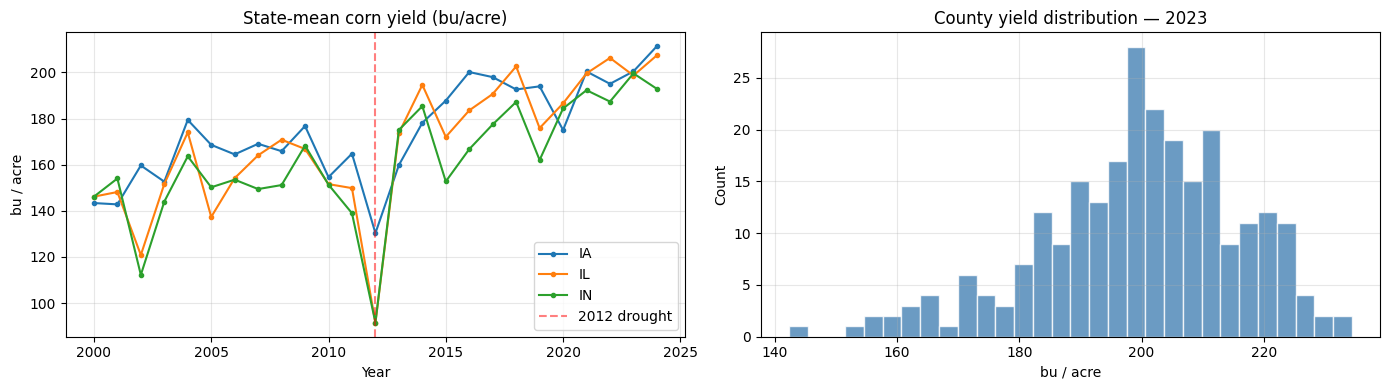

Plot saved to data/interim/nass_yield_overview.png


In [23]:
# ── 7.2  NASS yield time-series plot ──────────────────────────────────────────
nass_path = DATA_RAW / 'nass' / 'corn_yield_county_2000_2023.csv'
if nass_path.exists():
    nass_df = pd.read_csv(nass_path, dtype={'fips': str})

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: state-mean yield over time
    for state in STATES:
        sub = nass_df[nass_df['state'] == state].groupby('year')['yield_bu_acre'].mean()
        axes[0].plot(sub.index, sub.values, marker='o', markersize=3, label=state)
    axes[0].axvline(2012, color='red', linestyle='--', alpha=0.5, label='2012 drought')
    axes[0].set_title('State-mean corn yield (bu/acre)', fontsize=12)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('bu / acre')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: county yield distribution for most recent year
    latest_year = nass_df[nass_df['year'] <= 2023]['year'].max()
    latest = nass_df[nass_df['year'] == latest_year]['yield_bu_acre']
    axes[1].hist(latest, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].set_title(f'County yield distribution — {latest_year}', fontsize=12)
    axes[1].set_xlabel('bu / acre')
    axes[1].set_ylabel('Count')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_INTERIM / 'nass_yield_overview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Plot saved to data/interim/nass_yield_overview.png')
else:
    print('NASS file not found — run Section 1 first')

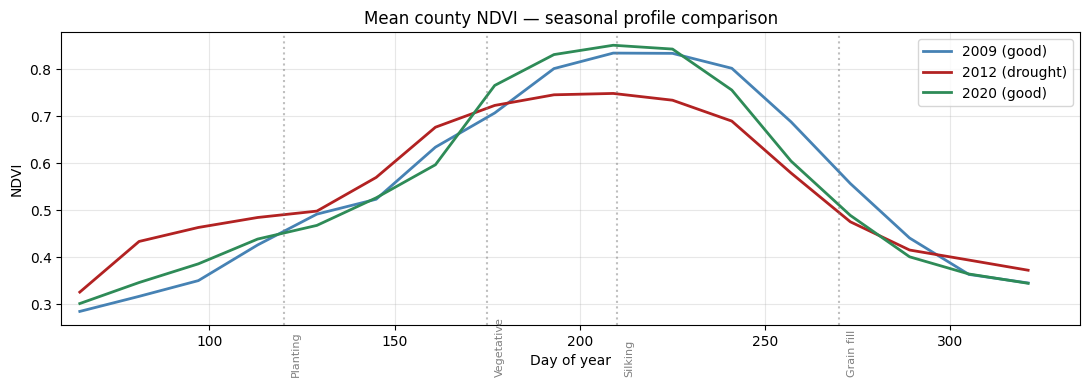

In [21]:
# ── 7.3  NDVI seasonal profile check ─────────────────────────────────────────
ndvi_path = DATA_RAW / 'modis' / 'ndvi_county_2000_2023.parquet'
if ndvi_path.exists():
    ndvi_df = pd.read_parquet(ndvi_path)
    ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
    ndvi_df['doy']  = ndvi_df['date'].dt.dayofyear

    # Compare a good year vs drought year
    fig, ax = plt.subplots(figsize=(11, 4))
    for year, col, label in [(2009, 'steelblue', '2009 (good)'),
                              (2012, 'firebrick', '2012 (drought)'),
                              (2020, 'seagreen',  '2020 (good)')]:
        sub = ndvi_df[ndvi_df['year'] == year].groupby('doy')['ndvi_mean'].mean()
        ax.plot(sub.index, sub.values, color=col, label=label, linewidth=2)

    ax.set_title('Mean county NDVI — seasonal profile comparison', fontsize=12)
    ax.set_xlabel('Day of year')
    ax.set_ylabel('NDVI')
    ax.set_xlim(60, 335)
    ax.legend()
    ax.grid(alpha=0.3)

    # Annotate growing season phases
    for x, lbl in [(120, 'Planting'), (175, 'Vegetative'), (210, 'Silking'), (270, 'Grain fill')]:
        ax.axvline(x, color='gray', linestyle=':', alpha=0.5)
        ax.text(x + 2, 0.15, lbl, fontsize=8, color='gray', rotation=90)

    plt.tight_layout()
    plt.savefig(DATA_INTERIM / 'ndvi_seasonal_profile.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('NDVI file not found — run Section 2 first')

In [22]:
# ── 7.4  Final data inventory ──────────────────────────────────────────────────
print('=' * 55)
print('  MODULE 1 COMPLETE — data inventory')
print('=' * 55)

checks = [
    ('NASS yield CSV',       DATA_RAW / 'nass'  / 'corn_yield_county_2000_2023.csv'),
    ('MODIS NDVI parquet',   DATA_RAW / 'modis' / 'ndvi_county_2000_2023.parquet'),
    ('SSURGO soil CSV',      DATA_RAW / 'soil'  / 'ssurgo_topsoil_corn_belt.csv'),
]

for label, path in checks:
    status = '✓' if path.exists() else '✗ MISSING'
    size   = f'{path.stat().st_size / 1e6:.1f} MB' if path.exists() else '—'
    print(f'  {status}  {label:<30} {size}')

era5_count   = len(list((DATA_RAW / 'era5').glob('*.nc')))
chirps_count = len(list((DATA_RAW / 'chirps').glob('*.nc')))
cdl_count    = len(list((DATA_RAW / 'cdl').glob('*.tif')))

print(f'  ℹ  ERA5 NetCDF files   : {era5_count}')
print(f'  ℹ  CHIRPS NetCDF files : {chirps_count}')
print(f'  ℹ  CDL GeoTIFF files   : {cdl_count}')
print()
print('  → Next: Module 2 — feature_engineering.ipynb')

  MODULE 1 COMPLETE — data inventory
  ✓  NASS yield CSV                 0.2 MB
  ✓  MODIS NDVI parquet             2.8 MB
  ✓  SSURGO soil CSV                0.0 MB
  ℹ  ERA5 NetCDF files   : 0
  ℹ  CHIRPS NetCDF files : 0
  ℹ  CDL GeoTIFF files   : 0

  → Next: Module 2 — feature_engineering.ipynb
